# Discriminant Analysis (LDA e QDA)

No notebook anterior modelamos $p(y \mid \mathbf{x})$ diretamente com regressão logística --- uma abordagem **discriminativa**. Neste notebook vamos atacar o mesmo problema de classificação por um caminho diferente: a abordagem **generativa**. A ideia é modelar a distribuição conjunta $p(\mathbf{x}, y)$ --- equivalentemente, o prior $\pi_k = p(y=k)$ junto com a densidade condicional $p(\mathbf{x} \mid y=k)$ --- e recuperar o classificador via teorema de Bayes.

Quando assumimos que cada $p(\mathbf{x} \mid y=k)$ é uma gaussiana multivariada, ganhamos dois classificadores muito clássicos:

- **LDA** (Linear Discriminant Analysis): supõe que todas as classes compartilham a mesma matriz de covariância $\boldsymbol{\Sigma}$. Resultado: fronteiras de decisão lineares.
- **QDA** (Quadratic Discriminant Analysis): cada classe tem sua própria $\boldsymbol{\Sigma}_k$. Resultado: fronteiras quadráticas (curvadas).

Neste notebook vamos:
1. Recapitular a abordagem generativa e a gaussiana multivariada;
2. Treinar LDA e QDA no dataset Iris e visualizar suas fronteiras de decisão;
3. Reproduzir o exemplo numérico do slide 158, em que estimamos $\hat{\boldsymbol{\Sigma}}_k$ por classe e descobrimos um problema clássico: as covariâncias amostrais resultantes são **singulares**;
4. Resolver a singularidade adicionando uma regularização $\varepsilon \mathbf{I}$;
5. Mostrar dois "bônus" da abordagem generativa que a discriminativa não tem: **gerar novos exemplos sintéticos** e **imputar valores ausentes** usando a estrutura gaussiana condicional;

(Conteúdo correspondente aos slides 146--159.)

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_iris
from sklearn.discriminant_analysis import (
    LinearDiscriminantAnalysis,
    QuadraticDiscriminantAnalysis,
)

%matplotlib inline
np.random.seed(42)

---
## 1. Abordagem generativa e teorema de Bayes

Em uma abordagem **generativa**, modelamos como os dados são produzidos. Para cada classe $k$, assumimos uma densidade condicional $p(\mathbf{x} \mid y = k)$ e um prior $\pi_k = p(y = k)$. O posterior, que é o que precisamos para classificar, sai do teorema de Bayes:
$$
\pi_k(\mathbf{x}) \;=\; p(y = k \mid \mathbf{x}) \;=\; \frac{p(\mathbf{x} \mid y = k)\,\pi_k}{\sum_{j=1}^{g} p(\mathbf{x} \mid y = j)\,\pi_j}.
$$
Como o denominador não depende de $k$, podemos comparar as classes pelos scores não normalizados $\pi_k \cdot p(\mathbf{x} \mid y = k)$ --- ou pelos seus logaritmos, que serão as funções discriminantes lineares (LDA) ou quadráticas (QDA).

A escolha específica que LDA e QDA fazem é assumir que cada $p(\mathbf{x} \mid y = k)$ é uma gaussiana multivariada $\mathcal{N}(\boldsymbol{\mu}_k, \boldsymbol{\Sigma}_k)$. A diferença entre os dois classificadores é se as matrizes $\boldsymbol{\Sigma}_k$ são **iguais** (LDA) ou **específicas por classe** (QDA).

---
## 2. A gaussiana multivariada - relembrando

Antes de treinar classificadores, vale visualizar como uma gaussiana 2D muda de cara dependendo da matriz de covariância. A densidade é
$$
p(\mathbf{x}) \;=\; \frac{1}{(2\pi)^{p/2}\,|\boldsymbol{\Sigma}|^{1/2}}\,\exp\!\left(-\tfrac{1}{2}(\mathbf{x} - \boldsymbol{\mu})^\top \boldsymbol{\Sigma}^{-1} (\mathbf{x} - \boldsymbol{\mu})\right),
$$
e suas curvas (curvas onde $p$ é constante) são elipses centradas em $\boldsymbol{\mu}$, com formato e orientação determinados por $\boldsymbol{\Sigma}$.

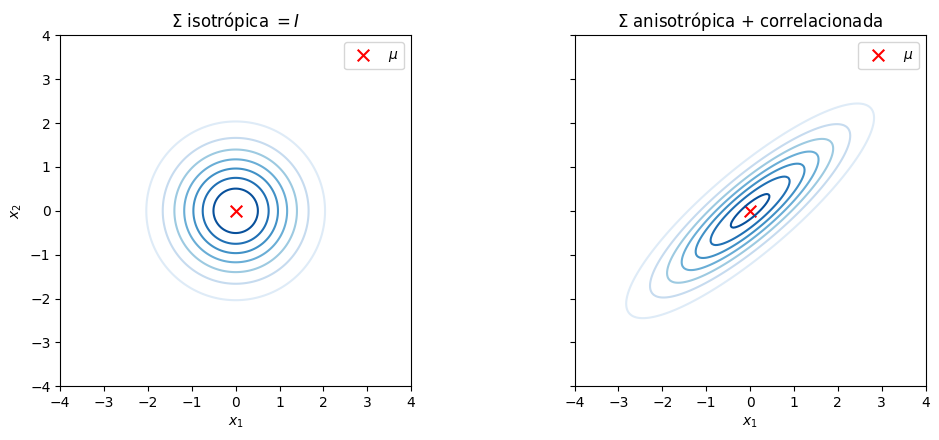

In [25]:
def gauss_density_2d(grid, mu, Sigma):
    """Avalia a densidade gaussiana 2D em uma grade de pontos."""
    diff = grid - mu
    inv = np.linalg.inv(Sigma)
    quad = np.einsum('ij,jk,ik->i', diff, inv, diff)
    norm = 1 / (2 * np.pi * np.sqrt(np.linalg.det(Sigma)))
    return norm * np.exp(-0.5 * quad)

xx, yy = np.meshgrid(np.linspace(-4, 4, 200), np.linspace(-4, 4, 200))
grid = np.column_stack([xx.ravel(), yy.ravel()])

mu = np.array([0.0, 0.0])
Sigma_iso   = np.array([[1.0, 0.0], [0.0, 1.0]])
Sigma_aniso = np.array([[2.0, 1.5], [1.5, 1.5]])

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5), sharey=True)
for ax, Sigma, title in [(axes[0], Sigma_iso,   r'$\Sigma$ isotrópica $= I$'),
                          (axes[1], Sigma_aniso, r'$\Sigma$ anisotrópica + correlacionada')]:
    z = gauss_density_2d(grid, mu, Sigma).reshape(xx.shape)
    ax.contour(xx, yy, z, levels=8, cmap='Blues')
    ax.scatter(*mu, color='red', s=70, marker='x', label=r'$\mu$')
    ax.set_xlabel(r'$x_1$'); ax.set_title(title)
    ax.set_aspect('equal'); ax.legend()
axes[0].set_ylabel(r'$x_2$')
plt.tight_layout(); plt.show()

Quando $\boldsymbol{\Sigma} = \mathbf{I}$ os contornos são círculos. Quando há variâncias desiguais e correlação entre as features, viram **elipses inclinadas** --- e é exatamente esse comportamento que LDA e QDA explorarão para definir as fronteiras de decisão entre classes.

---
## 3. Iris --- setup

Vamos trabalhar com o clássico dataset Iris. Ele tem 150 flores divididas em 3 espécies (`setosa`, `versicolor`, `virginica`), com 4 features cada (largura/comprimento de sépala e pétala). Para visualizar fronteiras de decisão em 2D, vamos restringir a duas features --- *Petal Length* e *Petal Width* --- exatamente como nos slides 151 e 156. Mais à frente, no exemplo de imputação, voltaremos às 4 features.

In [2]:
iris = load_iris()
X_full = iris.data            # (150, 4): sepal len/wid, petal len/wid
y_iris = iris.target          # 0 = setosa, 1 = versicolor, 2 = virginica
target_names = iris.target_names

# Subconjunto 2D: x = petal width (col 3), y = petal length (col 2) — segue ordem dos slides
X2 = X_full[:, [3, 2]]
print('X2 shape:', X2.shape)
print('classes:', list(target_names))

X2 shape: (150, 2)
classes: ['setosa', 'versicolor', 'virginica']


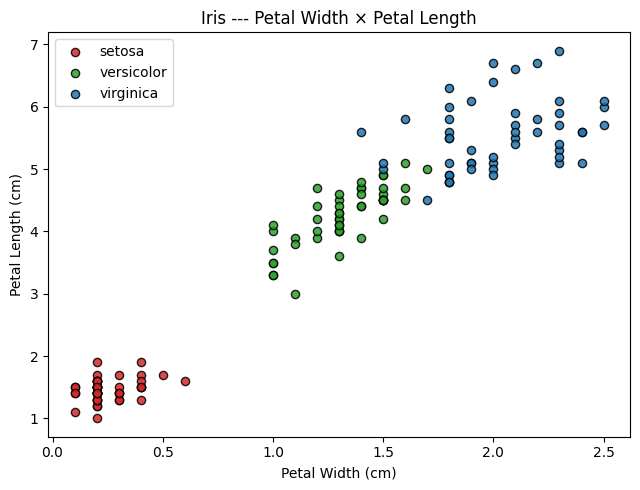

In [3]:
colors = ['tab:red', 'tab:green', 'tab:blue']

fig, ax = plt.subplots(figsize=(6.5, 5))
for k, name in enumerate(target_names):
    pts = X2[y_iris == k]
    ax.scatter(pts[:, 0], pts[:, 1], c=colors[k], edgecolors='black',
               s=35, alpha=0.85, label=name)
ax.set_xlabel('Petal Width (cm)'); ax.set_ylabel('Petal Length (cm)')
ax.set_title('Iris --- Petal Width × Petal Length')
ax.legend(); plt.tight_layout(); plt.show()

---
## 4. LDA no Iris

A LDA assume que as três classes são gaussianas com a **mesma** matriz de covariância $\boldsymbol{\Sigma}$. Vamos:

1. Estimar os parâmetros ($\hat\pi_k$, $\hat{\boldsymbol{\mu}}_k$, $\hat{\boldsymbol{\Sigma}}$ pooled) na mão;
2. Implementar o discriminante linear $f_k(\mathbf{x}) = w_{0k} + \mathbf{x}^\top \mathbf{w}_k$ derivado no slide 153;
3. Comparar com `sklearn.discriminant_analysis.LinearDiscriminantAnalysis`.

In [5]:
g = 3                # número de classes
n, p = X2.shape

priors = np.array([np.mean(y_iris == k) for k in range(g)])
means = np.array([X2[y_iris == k].mean(axis=0) for k in range(g)])

# Σ pooled = soma dos resíduos centrados de cada classe / (n - g)
Sigma_pooled = np.zeros((p, p))
for k in range(g):
    Xk = X2[y_iris == k]
    centered = Xk - means[k]
    Sigma_pooled += centered.T @ centered
Sigma_pooled /= (n - g)

print('priors:', priors)
print('means:'); print(means)
print('Σ pooled:'); print(Sigma_pooled)

priors: [0.33333333 0.33333333 0.33333333]
means:
[[0.246 1.462]
 [1.326 4.26 ]
 [2.026 5.552]]
Σ pooled:
[[0.04188163 0.04266531]
 [0.04266531 0.18518776]]


### 4.1 Discriminantes lineares e fronteira de decisão

Conforme derivado no slide 153, o discriminante de LDA para a classe $k$ é
$$
f_k(\mathbf{x}) \;=\; w_{0k} + \mathbf{x}^\top \mathbf{w}_k,
\quad \mathbf{w}_k = \boldsymbol{\Sigma}^{-1}\boldsymbol{\mu}_k,
\quad w_{0k} = \log \pi_k - \tfrac{1}{2}\boldsymbol{\mu}_k^\top \boldsymbol{\Sigma}^{-1}\boldsymbol{\mu}_k.
$$
A predição é simplesmente $\hat y(\mathbf{x}) = \arg\max_k f_k(\mathbf{x})$.

In [9]:
Sigma_inv = np.linalg.inv(Sigma_pooled)

W  = np.array([Sigma_inv @ means[k] for k in range(g)])                            # (g, p)
w0 = np.array([np.log(priors[k]) - 0.5 * means[k] @ Sigma_inv @ means[k]
               for k in range(g)])                                                   # (g,)

def lda_predict(X):
    scores = X @ W.T + w0     # (n_test, g)
    return scores.argmax(axis=1)

y_lda_manual = lda_predict(X2)
print(f'acurácia LDA manual: {(y_lda_manual == y_iris).mean():.4f}')

acurácia LDA manual: 0.9600


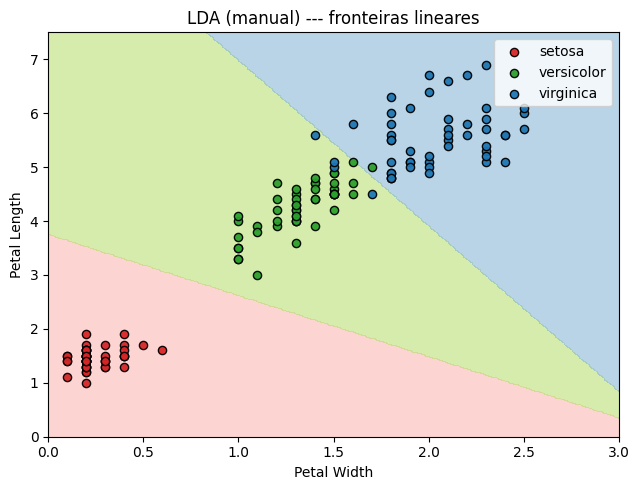

In [12]:
def plot_regions(predict_fn, title, X=X2, y=y_iris):
    xx, yy = np.meshgrid(np.linspace(0, 3, 300), np.linspace(0, 7.5, 300))
    grid = np.column_stack([xx.ravel(), yy.ravel()])
    Z = predict_fn(grid).reshape(xx.shape)
    fig, ax = plt.subplots(figsize=(6.5, 5))
    ax.contourf(xx, yy, Z, levels=[-0.5, 0.5, 1.5, 2.5],
                colors=['#fbb4ae', '#b3de69', '#80b1d3'], alpha=0.55)
    for k, name in enumerate(target_names):
        pts = X[y == k]
        ax.scatter(pts[:, 0], pts[:, 1], c=colors[k], edgecolors='black',
                   s=35, alpha=0.95, label=name)
    ax.set_xlabel('Petal Width'); ax.set_ylabel('Petal Length')
    ax.set_title(title); ax.legend()
    plt.tight_layout(); plt.show()

plot_regions(lda_predict, 'LDA (manual) --- fronteiras lineares')

### 4.2 Comparação com `sklearn`

A `LinearDiscriminantAnalysis` do `sklearn` deve produzir exatamente as mesmas predições.

In [13]:
clf_lda = LinearDiscriminantAnalysis()
clf_lda.fit(X2, y_iris)
y_lda_sk = clf_lda.predict(X2)

print(f'acurácia sklearn LDA: {(y_lda_sk == y_iris).mean():.4f}')
print(f'mesmas predições do LDA manual? {np.array_equal(y_lda_manual, y_lda_sk)}')

acurácia sklearn LDA: 0.9600
mesmas predições do LDA manual? True


---
## 5. QDA no Iris

A QDA libera a restrição de covariância igual: cada classe ganha sua própria $\boldsymbol{\Sigma}_k$. O discriminante (slide 156) vira **quadrático**:
$$
f_k(\mathbf{x}) \;=\; \log \pi_k - \tfrac{1}{2}\log|\boldsymbol{\Sigma}_k| - \tfrac{1}{2}\boldsymbol{\mu}_k^\top \boldsymbol{\Sigma}_k^{-1}\boldsymbol{\mu}_k + \mathbf{x}^\top \boldsymbol{\Sigma}_k^{-1}\boldsymbol{\mu}_k - \tfrac{1}{2}\mathbf{x}^\top \boldsymbol{\Sigma}_k^{-1}\mathbf{x}.
$$
O termo $-\tfrac{1}{2}\mathbf{x}^\top \boldsymbol{\Sigma}_k^{-1}\mathbf{x}$ depende de $k$ (porque $\boldsymbol{\Sigma}_k$ varia com $k$) --- é exatamente esse termo que torna a fronteira curva.

In [14]:
# Σ_k para cada classe (sample covariance, ddof=1)
Sigmas = np.array([np.cov(X2[y_iris == k].T, ddof=1) for k in range(g)])
print('Σ_k para cada classe:')
for k, name in enumerate(target_names):
    print(f'\n{name}:'); print(Sigmas[k])

Σ_k para cada classe:

setosa:
[[0.01110612 0.00606939]
 [0.00606939 0.03015918]]

versicolor:
[[0.03910612 0.07310204]
 [0.07310204 0.22081633]]

virginica:
[[0.07543265 0.04882449]
 [0.04882449 0.30458776]]


acurácia QDA manual: 0.9800


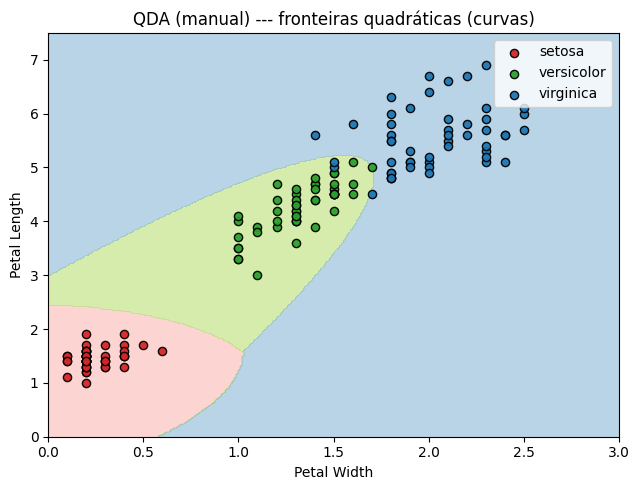

In [17]:
Sigmas_inv = np.array([np.linalg.inv(S) for S in Sigmas])
log_dets = np.array([np.log(np.linalg.det(S)) for S in Sigmas])

def qda_predict(X):
    n_test = X.shape[0]
    scores = np.zeros((n_test, g))
    for k in range(g):
        # Ver slide 156, e notem que a expressão de p(x | y = k) é retirada do slide 154 (e calculada como no slide 154)
        diff = X - means[k]  # (n, p)
        # diff @ Σ⁻¹ tem shape (n, p); multiplico elemento-a-elemento
        # por diff e somo ao longo das features → vetor (n,).
        quad = ((diff @ Sigmas_inv[k]) * diff).sum(axis=1)        # (n,)
        scores[:, k] = np.log(priors[k]) - 0.5 * log_dets[k] - 0.5 * quad
    return scores.argmax(axis=1)

y_qda_manual = qda_predict(X2)
print(f'acurácia QDA manual: {(y_qda_manual == y_iris).mean():.4f}')

plot_regions(qda_predict, 'QDA (manual) --- fronteiras quadráticas (curvas)')

### 5.1 Comparação com `sklearn`

In [18]:
clf_qda = QuadraticDiscriminantAnalysis()
clf_qda.fit(X2, y_iris)
y_qda_sk = clf_qda.predict(X2)

print(f'acurácia sklearn QDA: {(y_qda_sk == y_iris).mean():.4f}')
print(f'mesmas predições do QDA manual? {np.array_equal(y_qda_manual, y_qda_sk)}')

acurácia sklearn QDA: 0.9800
mesmas predições do QDA manual? True


Compare visualmente as fronteiras de LDA (linha reta) e QDA (curva). No Iris, com features bem separadas, a diferença de acurácia é pequena, mas o **formato** das fronteiras é completamente diferente.

---
## 6. O exemplo do slide 158: matrizes singulares e o conserto com $\varepsilon$

O slide 158 mostra um exemplo com **5 pontos em 2D**, divididos em duas classes:

- Classe 1 (2 pontos): $\mathbf{x}_1 = (1, 2)^\top$, $\mathbf{x}_2 = (2, 3)^\top$
- Classe 2 (3 pontos): $\mathbf{x}_3 = (6, 8)^\top$, $\mathbf{x}_4 = (7, 9)^\top$, $\mathbf{x}_5 = (8, 10)^\top$

Vamos refazer todos os cálculos passo a passo e bater com o slide. Em seguida, mostramos um fenômeno importante: as covariâncias amostrais $\hat{\boldsymbol{\Sigma}}_k$ que aparecem aqui são **singulares** (posto 1, determinante zero), porque os pontos em cada classe são colineares --- e por isso a QDA não consegue invertê-las. A solução padrão é a regularização $\hat{\boldsymbol{\Sigma}}_k + \varepsilon \mathbf{I}$.

In [19]:
X_toy = np.array([
    [1.0, 2.0],   # x1, classe 1
    [2.0, 3.0],   # x2, classe 1
    [6.0, 8.0],   # x3, classe 2
    [7.0, 9.0],   # x4, classe 2
    [8.0, 10.0],  # x5, classe 2
])
y_toy = np.array([0, 0, 1, 1, 1])

priors_toy = np.array([np.mean(y_toy == k) for k in range(2)])
means_toy  = np.array([X_toy[y_toy == k].mean(axis=0) for k in range(2)])
Sigmas_toy = np.array([np.cov(X_toy[y_toy == k].T, ddof=1) for k in range(2)])

print(f'priors: π_1 = {priors_toy[0]}, π_2 = {priors_toy[1]}')
print(f'μ_1 = {means_toy[0]}   (esperado: [1.5, 2.5])')
print(f'μ_2 = {means_toy[1]}   (esperado: [7. , 9. ])')
print(f'\nΣ_1 =\n{Sigmas_toy[0]}\n(esperado: [[0.5, 0.5], [0.5, 0.5]])')
print(f'\nΣ_2 =\n{Sigmas_toy[1]}\n(esperado: [[1. , 1. ], [1. , 1. ]])')

priors: π_1 = 0.4, π_2 = 0.6
μ_1 = [1.5 2.5]   (esperado: [1.5, 2.5])
μ_2 = [7. 9.]   (esperado: [7. , 9. ])

Σ_1 =
[[0.5 0.5]
 [0.5 0.5]]
(esperado: [[0.5, 0.5], [0.5, 0.5]])

Σ_2 =
[[1. 1.]
 [1. 1.]]
(esperado: [[1. , 1. ], [1. , 1. ]])


### 6.1 As covariâncias são singulares

Os números batem com o slide. Mas note o problema: os dois pontos da classe 1 estão na reta $y = x + 1$, e os três da classe 2 na reta $y = x + 2$. Em cada classe, todos os resíduos centrados apontam na mesma direção $(1, 1)$, e isso faz com que $\hat{\boldsymbol{\Sigma}}_k$ tenha **posto 1** --- singular, não invertível.

In [20]:
for k, S in enumerate(Sigmas_toy, start=1):
    print(f'Σ_{k}: det = {np.linalg.det(S):.2e},  posto = {np.linalg.matrix_rank(S)}')

print('\nTentando inverter Σ_1:')
try:
    inv1 = np.linalg.inv(Sigmas_toy[0])
    print('inverteu:'); print(inv1)
except np.linalg.LinAlgError as e:
    print(f'  → np.linalg.LinAlgError: {e}')

Σ_1: det = 0.00e+00,  posto = 1
Σ_2: det = 0.00e+00,  posto = 1

Tentando inverter Σ_1:
  → np.linalg.LinAlgError: Singular matrix


Como esperado, `np.linalg.inv` falha. Sem o conserto, o classificador QDA não consegue nem ser construído nesses dados.

### 6.2 O conserto: regularização $\varepsilon \mathbf{I}$

O remédio padrão é adicionar uma pequena matriz identidade escalada à covariância:
$$
\hat{\boldsymbol{\Sigma}}_k^{\text{reg}} \;=\; \hat{\boldsymbol{\Sigma}}_k + \varepsilon \mathbf{I},
$$
com $\varepsilon$ pequeno (por exemplo, $10^{-3}$). Isso (i) levanta os autovalores nulos para $\varepsilon$, tornando a matriz positiva-definida e invertível; (ii) interpreta-se como adicionar uma pequena variância isotrópica em cada feature.

(`sklearn` chama essa abordagem de `reg_param` no `QuadraticDiscriminantAnalysis`. Existem variantes mais sofisticadas --- shrinkage de Ledoit-Wolf, por exemplo --- mas o princípio é o mesmo.)

In [21]:
eps = 1e-3
Sigmas_toy_reg = np.array([S + eps * np.eye(2) for S in Sigmas_toy])

for k, S in enumerate(Sigmas_toy_reg, start=1):
    det = np.linalg.det(S)
    cond = np.linalg.cond(S)
    print(f'Σ_{k}^reg: det = {det:.5f},  cond = {cond:.2e}')

inv1_reg = np.linalg.inv(Sigmas_toy_reg[0])
print('\nΣ_1^reg invertida (existe!):')
print(inv1_reg.round(2))

Σ_1^reg: det = 0.00100,  cond = 1.00e+03
Σ_2^reg: det = 0.00200,  cond = 2.00e+03

Σ_1^reg invertida (existe!):
[[ 500.5 -499.5]
 [-499.5  500.5]]


O determinante deixa de ser zero (vira da ordem de $\varepsilon$), e a matriz passa a ser invertível. O número de condicionamento ainda é alto (a matriz é "quase" singular), mas isso é aceitável.

### 6.3 Classificando um ponto novo com QDA regularizada

Vamos pegar um ponto $\mathbf{x}_\ast = (4, 5)$ e ver como a QDA regularizada o classifica. Note que $\mathbf{x}_\ast$ está exatamente na reta $y = x + 1$, que é a reta da classe 1 --- esperamos que o classificador favoreça a classe 1 com folga.

In [22]:
def qda_score(x, mu, Sigma_inv, log_det, prior):
    diff = x - mu
    return np.log(prior) - 0.5 * log_det - 0.5 * diff @ Sigma_inv @ diff

x_star = np.array([4.0, 5.0])
log_dets_reg = np.array([np.log(np.linalg.det(S)) for S in Sigmas_toy_reg])
inv_reg = np.array([np.linalg.inv(S) for S in Sigmas_toy_reg])

scores = np.array([qda_score(x_star, means_toy[k], inv_reg[k],
                              log_dets_reg[k], priors_toy[k]) for k in range(2)])
print(f'score classe 1: {scores[0]:+.3f}')
print(f'score classe 2: {scores[1]:+.3f}')
print(f'predição da QDA manual:    classe {scores.argmax() + 1}')

clf_toy = QuadraticDiscriminantAnalysis(reg_param=eps)
clf_toy.fit(X_toy, y_toy)
print(f'predição do sklearn QDA:   classe {clf_toy.predict([x_star])[0] + 1}')

score classe 1: -3.707
score classe 2: -253.526
predição da QDA manual:    classe 1
predição do sklearn QDA:   classe 1


A classe 1 vence por uma margem enorme (centenas de unidades em log-score), porque o ponto está exatamente sobre a "espinha" da nuvem da classe 1, mas perpendicular à da classe 2 --- e a covariância regularizada da classe 2 tem variância muito pequena nessa direção perpendicular, o que dispara a Mahalanobis.

---
## 7. Bônus generativo #1: gerar exemplos sintéticos

Como ajustamos uma gaussiana por classe, podemos **amostrar** dela para criar novos exemplos sintéticos da mesma "população". Esse é um bônus que classificadores discriminativos (como a regressão logística) não oferecem: eles modelam $p(y \mid \mathbf{x})$, mas não sabem nada sobre $p(\mathbf{x})$.

Aplicação típica: aumento de dados (data augmentation) para classes minoritárias, ou simulação de cenários hipotéticos.

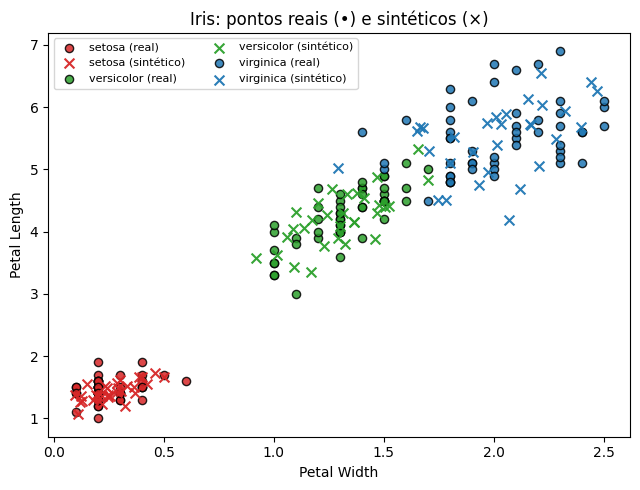

In [23]:
rng = np.random.default_rng(0)
n_synth = 30  # por classe

X_synth, y_synth = [], []
for k in range(g):
    samples = rng.multivariate_normal(means[k], Sigmas[k], size=n_synth)
    X_synth.append(samples)
    y_synth.append(np.full(n_synth, k))
X_synth = np.vstack(X_synth)
y_synth = np.concatenate(y_synth)

fig, ax = plt.subplots(figsize=(6.5, 5))
for k, name in enumerate(target_names):
    real  = X2[y_iris == k]
    synth = X_synth[y_synth == k]
    ax.scatter(real[:, 0],  real[:, 1],  c=colors[k], edgecolors='black',
               s=35, alpha=0.85, label=f'{name} (real)')
    ax.scatter(synth[:, 0], synth[:, 1], c=colors[k], marker='x',
               s=50, alpha=0.95, label=f'{name} (sintético)')
ax.set_xlabel('Petal Width'); ax.set_ylabel('Petal Length')
ax.set_title('Iris: pontos reais (•) e sintéticos (×)')
ax.legend(fontsize=8, ncol=2); plt.tight_layout(); plt.show()

Os pontos sintéticos seguem o formato de cada nuvem original, com leve "vazamento" para fora delas --- isso é esperado, já que uma gaussiana com cauda infinita ocasionalmente produz amostras nas bordas que a distribuição real (limitada a valores não negativos, por exemplo) nunca produziria. Para a maioria das aplicações de data augmentation, isso é aceitável.

---
## 8. Bônus generativo #2: imputar valores ausentes

A propriedade fundamental que permite imputação é a seguinte: se $\mathbf{x} \sim \mathcal{N}(\boldsymbol{\mu}, \boldsymbol{\Sigma})$ e particionamos $\mathbf{x} = (\mathbf{x}_a, \mathbf{x}_b)$ em parte "observada" $a$ e parte "ausente" $b$, então $\mathbf{x}_b$ dado $\mathbf{x}_a$ **também é gaussiano**, com média condicional
$$
\mathbb{E}[\mathbf{x}_b \mid \mathbf{x}_a] \;=\; \boldsymbol{\mu}_b + \boldsymbol{\Sigma}_{ba}\,\boldsymbol{\Sigma}_{aa}^{-1}\,(\mathbf{x}_a - \boldsymbol{\mu}_a),
$$
e covariância condicional $\boldsymbol{\Sigma}_{bb} - \boldsymbol{\Sigma}_{ba}\,\boldsymbol{\Sigma}_{aa}^{-1}\,\boldsymbol{\Sigma}_{ab}$.

Isso transforma cada classe em uma "máquina de imputação": dada uma flor com algumas features faltando, conhecemos sua classe $\to$ temos $\boldsymbol{\mu}_k$ e $\boldsymbol{\Sigma}_k$ $\to$ calculamos a média condicional para preencher as features ausentes.

Vamos demonstrar com Iris (4 features). Pretendemos que **Petal Width** está ausente; queremos imputá-la a partir das outras três features (sepal length, sepal width, petal length), assumindo a classe verdadeira conhecida.

In [24]:
def conditional_mean(mu, Sigma, x_obs, obs_idx, missing_idx):
    """E[x[missing] | x[obs]] sob N(mu, Sigma)."""
    mu_a, mu_b = mu[obs_idx], mu[missing_idx]
    Sigma_aa = Sigma[np.ix_(obs_idx, obs_idx)]
    Sigma_ba = Sigma[np.ix_(missing_idx, obs_idx)]
    return mu_b + Sigma_ba @ np.linalg.inv(Sigma_aa) @ (x_obs - mu_a)

# Estima parâmetros nas 4 features (com pequena regularização para garantir inversibilidade)
means4 = np.array([X_full[y_iris == k].mean(axis=0) for k in range(g)])
Sigmas4 = np.array([np.cov(X_full[y_iris == k].T, ddof=1) + 1e-4 * np.eye(4)
                    for k in range(g)])

obs_idx     = [0, 1, 2]   # sepal length, sepal width, petal length
missing_idx = [3]         # petal width (a feature "ausente")

# Imputa petal width para cada flor usando a classe verdadeira
imputed = np.array([
    conditional_mean(means4[ki], Sigmas4[ki], xi[obs_idx], obs_idx, missing_idx)[0]
    for xi, ki in zip(X_full, y_iris)
])

true_pw = X_full[:, 3]
mae = np.mean(np.abs(imputed - true_pw))
print(f'MAE da imputação de Petal Width: {mae:.4f}')
print(f'(Petal Width vai de {true_pw.min():.1f} a {true_pw.max():.1f} cm)')

MAE da imputação de Petal Width: 0.1139
(Petal Width vai de 0.1 a 2.5 cm)


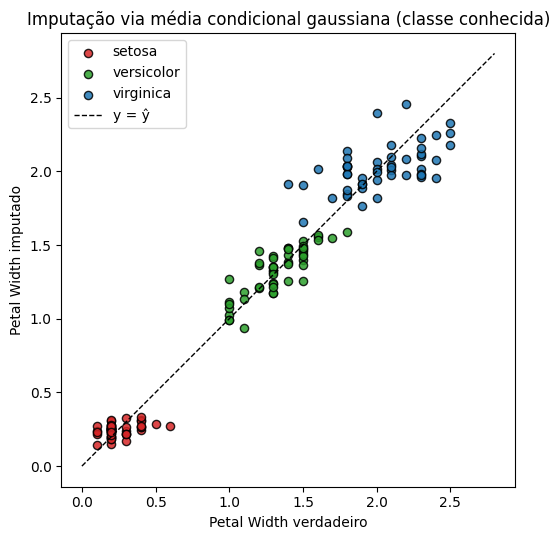

In [25]:
fig, ax = plt.subplots(figsize=(6, 5.5))
for k, name in enumerate(target_names):
    mask = y_iris == k
    ax.scatter(true_pw[mask], imputed[mask], c=colors[k], edgecolors='black',
               s=35, alpha=0.85, label=name)
lims = [0, true_pw.max() + 0.3]
ax.plot(lims, lims, 'k--', linewidth=1, label='y = ŷ')
ax.set_xlabel('Petal Width verdadeiro')
ax.set_ylabel('Petal Width imputado')
ax.set_title('Imputação via média condicional gaussiana (classe conhecida)')
ax.legend(); ax.set_aspect('equal')
plt.tight_layout(); plt.show()

Os pontos seguem a diagonal de perto --- mesmo sem ver `petal_width`, a estrutura conjunta gaussiana das 4 features (mais o conhecimento da classe) recupera o valor com erro médio bem pequeno.

E quando a classe **não** é conhecida? Basta classificar primeiro pelas features observadas (treinando um LDA/QDA nas 3 features visíveis) e em seguida usar $\boldsymbol{\mu}_{\hat k}, \boldsymbol{\Sigma}_{\hat k}$ na média condicional. Uma alternativa mais "marginal" é misturar as imputações de todas as classes ponderadas pelos posteriores $\pi_k(\mathbf{x}_{\text{obs}})$ --- isso vira uma média condicional sob a mistura $\sum_k \pi_k \mathcal{N}(\boldsymbol{\mu}_k, \boldsymbol{\Sigma}_k)$.

Note como o erro do QDA **dispara** conforme $p$ cresce: estimar uma matriz $p \times p$ por classe pede ordens de grandeza mais dados do que estimar uma única $\boldsymbol{\Sigma}$ pooled. O LDA, mesmo violando a hipótese de covariância igual, vence em regime de poucos dados / muitas features. É o **bias-variance trade-off** em ação --- mais flexibilidade nem sempre é melhor.

---
## 10. Resumo

| Aspecto | LDA | QDA |
|---|---|---|
| Hipótese sobre $\boldsymbol{\Sigma}_k$ | iguais ($\boldsymbol{\Sigma}_k \equiv \boldsymbol{\Sigma}$) | livres (uma por classe) |
| Discriminante | $f_k(\mathbf{x}) = w_{0k} + \mathbf{x}^\top \mathbf{w}_k$ | quadrático em $\mathbf{x}$ |
| Fronteira de decisão | hiperplano | curva quadrática |
| Nº de parâmetros de cov. | $\tfrac{p(p+1)}{2}$ | $g \cdot \tfrac{p(p+1)}{2}$ |
| Robustez em alta dim. | melhor (pooling reduz variância) | sofre |

O que ganhamos seguindo a abordagem **generativa** (LDA/QDA), em vez da discriminativa (regressão logística):

1. Acesso à densidade $p(\mathbf{x} \mid y)$ → podemos **gerar exemplos sintéticos**, úteis para data augmentation;
2. Acesso à estrutura conjunta de $\mathbf{x}$ → podemos **imputar features ausentes** via a média condicional gaussiana;
3. Em troca, comprometemos o modelo com uma forma específica para os dados (gaussianas), que pode ou não ser realista.

Em todos os casos, a singularidade das $\hat{\boldsymbol{\Sigma}}_k$ (especialmente em alta dimensão ou com poucos dados por classe) é resolvida adicionando $\varepsilon \mathbf{I}$ --- uma forma simples e eficaz de regularização, que `sklearn` expõe como `reg_param`.